In [62]:
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 1.参数文件

In [57]:
class Arguments(object):
    bert_dir = '/Users/bowie/Documents/muti-model/bert-base-chinese'
    data_dir = '/Users/bowie/Documents/muti-data/nlp-意图识别/SMP2019/data.json'

    # 找出intent和slot
    # 以及text的最大长度
    with open(data_dir, 'r', encoding="utf-8") as f:
        data = json.load(f)
    
    intent_lst = []
    slot_lst = []
    slot_ner = ['O']
    text_max_len = 0

    for i in data:
        if i['intent'] not in intent_lst:
            intent_lst.append(i['intent'])
        for k,v in i['slots'].items():
            if k not in slot_lst:
                slot_lst.append(k)
                slot_ner.append(f'B-{k}')
                slot_ner.append(f'I-{k}')
        if len(i['text']) > text_max_len:
            text_max_len = len(i['text'])

    intent_num = len(intent_lst)
    slot_num = len(slot_ner)

    print('intent为: ', intent_num, intent_lst)
    print('slot为: ', len(slot_lst), slot_lst)
    print('slot_ner为: ', slot_num, slot_ner)
    print('text的最大长度为: ', text_max_len)

    # intent的id映射
    id2cls = {}
    cls2id = {}
    for ind, val in enumerate(intent_lst):
        id2cls[ind] = val
        cls2id[val] = ind
    print('id2cls: ', id2cls)
    print('cls2id: ', cls2id)
    
    # ner的id映射
    id2label = {}
    label2id = {}
    for ind, val in enumerate(slot_ner):
        id2label[ind] = val
        label2id[val] = ind

    print('id2label: ', id2label)
    print('label2id: ', label2id)
    # 2.参数设置
    hidden_size = 768
    hidden_dropout = 0.1
    max_len = 32
    # batch_size = 32
    lr=5e-5
    epoch = 50


args = Arguments()

intent为:  23 ['LAUNCH', 'QUERY', 'ROUTE', 'SENDCONTACTS', 'SEND', 'REPLY', 'REPLAY_ALL', 'LOOK_BACK', 'NUMBER_QUERY', 'POSITION', 'PLAY', 'DEFAULT', 'DIAL', 'TRANSLATION', 'OPEN', 'CREATE', 'FORWARD', 'VIEW', 'SEARCH', 'RISERATE_QUERY', 'DOWNLOAD', 'DATE_QUERY', 'CLOSEPRICE_QUERY']
slot为:  60 ['name', 'Dest', 'Src', 'endLoc_city', 'theatre', 'datetime_time', 'receiver', 'dishName', 'ingredient', 'utensil', 'content', 'datetime_date', 'tvchannel', 'category', 'startLoc_city', 'startDate_date', 'startLoc_poi', 'keyword', 'location_province', 'endLoc_poi', 'endLoc_province', 'location_area', 'location_poi', 'endLoc_area', 'type', 'song', 'artist', 'location_city', 'media', 'popularity', 'author', 'dynasty', 'queryField', 'code', 'startLoc_area', 'startDate_time', 'target', 'resolution', 'tag', 'area', 'film', 'relIssue', 'absIssue', 'headNum', 'teleOperator', 'timeDescr', 'scoreDescr', 'subfocus', 'homeName', 'awayName', 'location_country', 'yesterday', 'startLoc_province', 'episode', 'ar

## 一 数据处理

In [11]:
with open(args.data_dir, 'r', encoding="utf-8") as f:
    data = json.load(f)

train_data, val_data = [], []
intent = {}
# 按照 intent 分类，然后按照 8:2 划分训练集和验证集
for item in data:
    if item['intent'] not in intent.keys():
        intent[item['intent']] = [item]
    else:
        intent[item['intent']].append(item)

# print(intent)
for key, value in intent.items():
    train = value[:int(len(value) * 0.8)]
    val = value[int(len(value) * 0.8):]
    train_data.extend(train)
    val_data.extend(val)

random.shuffle(train_data)
random.shuffle(val_data)
json.dump(train_data, open('train.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=4)
json.dump(val_data, open('val.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=4)
print(len(train_data), len(val_data))

2106 538


### 1.1 数据标注处理

In [41]:
tokenizer = BertTokenizer.from_pretrained(args.bert_dir)
# 自定义词典，避免分词将CCTV7拆开
# new_tokens = ['CCTV7']
# tokenizer.add_tokens(new_tokens)

/Users/bowie/anaconda3/envs/good/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [40]:
def tag_text(data):
    text = data['text']
    slots = data['slots']
    intent = data['intent']
    # tokens = list(text)  # 这里以字符为单位，如果需要以词为单位，可以修改为分词方式
    tokens = tokenizer.tokenize(text)
    # print(len(tokens), tokens)
    tags = [0] * len(tokens)  # 初始化所有的标签为 'O'


    def find_sublist(a, b):
        len_b = len(b)
        for i in range(len(a) - len_b + 1):
            if a[i:i+len_b] == b:  # 判断从索引 i 开始的子列表是否等于 b
                start_idx = i
                end_idx = i + len_b - 1
                return start_idx, end_idx
    
    for slot_name, slot_value in slots.items():
        # 找到 slot 值在文本中的起始位置
        slot_token = tokenizer.tokenize(slot_value)
        start_idx, end_idx = find_sublist(tokens, slot_token)

        # tags[start_idx] = f'B-{slot_name}'  # 起始位置打 'B-'
        tags[start_idx] = args.label2id[f'B-{slot_name}']
        # 去掉第一个字 然后range在加一个数
        for i in range(start_idx+1, end_idx+1):
            # tags[i] = f'I-{slot_name}'  # 后续位置打 'I-'
            tags[i] = args.label2id[f'I-{slot_name}']
    
    # print(len(tags), tags)
    # 对齐标签和 token 序列的长度
    if len(tags) < args.max_len:
        # 101 + tags + 102 + 0
        tags = [0] + tags + [0] * (args.max_len - len(tags) - 1)
    # return tokens, tags
    inputs = tokenizer(
        text=text,              # 要编码的输入文本，即 i['text']，其中 i 是包含文本信息的字典
        max_length=args.max_len,      # 设定编码后的最大长度。token 序列会被截断或填充到这个长度
        padding='max_length',         # 对 token 序列进行填充（padding）以使其达到 max_length 长度。如果不足，就用填充符号（如 0）补足
        truncation='only_first',      # 如果输入的 token 序列超出了 max_length 长度，裁剪（截断）文本中的第一个句子（常用于句子对的输入）
        return_attention_mask=True,   # 返回 attention_mask，用于指示哪些 token 是实际文本，哪些是填充（1 表示文本 token，0 表示填充值）
        return_token_type_ids=True,   # 返回 token_type_ids，用于区分句子对（BERT 使用 token_type_ids 来区分不同的句子）
    )

    '''
    requires_grad=False：这是张量的一个属性，指定该张量是否需要在训练时计算梯度。

    当 requires_grad=False 时，PyTorch 不会为这个张量计算梯度（即它不会在反向传播过程中更新）。这种设置通常用于模型的输入，或者用于不需要梯度的变量（例如在推理阶段）。
    如果设置为 True，这个张量将在反向传播中计算梯度，用于更新参数（通常在训练阶段需要）。
    '''
    return {
        'text': text, # 排查问题用的
        'input_ids': torch.tensor(inputs['input_ids'], requires_grad=False),
        'attention_mask': torch.tensor(inputs['attention_mask'], requires_grad=False),
        'token_type_ids': torch.tensor(inputs['token_type_ids'], requires_grad=False),
        'seq_label_ids': torch.tensor(args.cls2id[intent], requires_grad=False),
        'token_label_ids': torch.tensor(tags, requires_grad=False),
    }


In [42]:
with open('train.json', 'r', encoding="utf-8") as f:
    train_data = json.load(f)

train_data_lst = [tag_text(i) for i in train_data]
print(len(train_data_lst), train_data_lst[:2])

2105 [{'text': '得了艾滋病怎么办', 'input_ids': tensor([ 101, 2533,  749, 5687, 3996, 4567, 2582,  720, 1215,  102,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0]), 'seq_label_ids': tensor(1), 'token_label_ids': tensor([ 0,  0,  0, 35, 36, 36,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])}, {'text': '南山医院到北大医院路线', 'input_ids': tensor([ 101, 1298, 2255, 1278, 7368, 1168, 1266, 1920, 1278, 7368, 6662, 5296,
         102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 

In [46]:
with open('val.json', 'r', encoding="utf-8") as f:
    val_data = json.load(f)

val_data_lst = [tag_text(i) for i in val_data]
print(len(val_data_lst), val_data_lst[:2])

538 [{'text': '来首苏轼的词。', 'input_ids': tensor([ 101, 3341, 7674, 5722, 6769, 4638, 6404,  511,  102,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0]), 'seq_label_ids': tensor(1), 'token_label_ids': tensor([ 0,  0,  0, 61, 62,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])}, {'text': 'BTVKAKU少儿', 'input_ids': tensor([ 101, 8364, 8225, 8693, 9547, 2208, 1036,  102,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1

In [43]:
# 自定义数据集类
class CAIDataset(Dataset):
    def __init__(self, data):
        # 初始化数据和标签
        self.data = data

    def __len__(self):
        # 返回数据集的大小
        return len(self.data)

    def __getitem__(self, idx):
        # 根据索引返回一个样本及其对应的标签
        sample = {
            'text': self.data[idx]['text'],
            'input_ids': self.data[idx]['input_ids'],
            'attention_mask': self.data[idx]['attention_mask'],
            'token_type_ids': self.data[idx]['token_type_ids'],
            'seq_label_ids': self.data[idx]['seq_label_ids'],
            'token_label_ids': self.data[idx]['token_label_ids'],
        }
        return sample


In [44]:
# 实例化自定义数据集
train_dataset = CAIDataset(train_data_lst)

# 使用DataLoader加载数据，batch_size为32
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# 迭代数据集
for batch_data in train_dataloader:
    print(batch_data)
    break


{'text': ['鱼香肉丝，怎么炒？', '打电话给王安娜', '我想吃汉堡包的英文怎么说', '拨号曹兴发'], 'input_ids': tensor([[ 101, 7824, 7676, 5489,  692, 8024, 2582,  720, 4143, 8043,  102,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 2802, 4510, 6413, 5314, 4374, 2128, 2025,  102,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 2769, 2682, 1391, 3727, 1836, 1259, 4638, 5739, 3152, 2582,  720,
         6432,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 2884, 1384, 3293, 1069, 1355,  102,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 

In [47]:
# 实例化自定义数据集
val_dataset = CAIDataset(val_data_lst)

# 使用DataLoader加载数据，batch_size为32
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=True)

# 迭代数据集
for batch_data in val_dataloader:
    print(batch_data)
    break

{'text': ['独立纵队电视剧', '查一下到长途汽车站去的最省钱的线路', '给杨李鹏发短信', '看上周五的爸爸我去哪儿'], 'input_ids': tensor([[ 101, 4324, 4989, 5288, 7339, 4510, 6228, 1196,  102,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 3389,  671,  678, 1168, 7270, 6854, 3749, 6756, 4991, 1343, 4638,
         3297, 4689, 7178, 4638, 5296, 6662,  102,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 5314, 3342, 3330, 7905, 1355, 4764,  928,  102,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 4692,  677, 1453,  758, 4638, 4268, 4268, 2769, 1343, 1525, 1036,
          102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 

## 二 搭建模型

In [10]:
class IntentClassifier(nn.Module):
    def __init__(self, config):
        super(IntentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(config.bert_dir)

        # Sequential 类似 keras 的容器，可以放多个层 可以放激活函数
        self.intent_classification = nn.Sequential(
            nn.Dropout(config.hidden_dropout),
            nn.Linear(config.hidden_size, config.intent_num),
        )
        self.slot_ner = nn.Sequential(
            nn.Dropout(config.hidden_dropout),
            nn.Linear(config.hidden_size, config.slot_num)
        )

    def forward(self, input_ids, attention_mask, token_type_ids):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        # 这是 BERT 的池化输出，通常是代表整个序列的嵌入，适用于序列级任务，比如意图分类。池化输出是 BERT 对输入序列的整体表示。
        pooler_output = bert_output[1]
        # 这是 BERT 的最后一层输出，对每个 token 都有一个表示，适用于 token 级任务，比如槽位填充。这个输出保留了每个 token 的详细信息。
        token_output = bert_output[0]

        intent_logits = self.intent_classification(pooler_output)
        slot_logits = self.slot_ner(token_output)
        return intent_logits, slot_logits


    

In [11]:
model = IntentClassifier(config=args)
model.to(device)

A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Pl

IntentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [26]:
# 定义 AdamW 优化器
'''
AdamW 是最常用的优化器，尤其适用于预训练的 Transformer 模型（如 BERT）。相比于标准的 Adam 优化器，AdamW 在权重衰减上有所改进，可以避免过拟合，并且它是 Hugging Face 推荐的优化器。
推荐原因：
BERT 等模型通常使用 AdamW，并且 Hugging Face transformers 库的官方实现也默认使用它。
内置的权重衰减机制有助于提升模型的泛化能力。

lr（学习率）：通常对于微调 BERT 等预训练模型，学习率范围推荐在 2e-5 到 5e-5 之间。
weight_decay（权重衰减）：避免过拟合，通常设置为 0.01 左右。
'''
optimizer = AdamW(model.parameters(), lr=args.lr, weight_decay=0.01)

/Users/bowie/anaconda3/envs/good/lib/python3.9/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


### 2.2 训练模型

In [58]:
total_step = len(train_dataloader) * args.epoch
y_total_step = len(val_dataloader) * args.epoch

train_losses = []
val_losses = []

for epoch in range(args.epoch):
    model.train()
    global_step = 1
    train_loss = 0.0
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        seq_label_ids = batch['seq_label_ids'].to(device)
        token_label_ids = batch['token_label_ids'].to(device)

        # 清除累积的梯度
        '''
        主要区别：
        optimizer.zero_grad()：会清除由 optimizer 管理的所有参数的梯度。这是最常用的方法，因为优化器内部知道它管理的参数，因此它可以有效地清除这些参数的梯度。
        model.zero_grad()：会清除模型中所有参数的梯度。这和 optimizer.zero_grad() 类似，但如果你使用多个优化器（比如对不同的参数使用不同的优化器），则这会清除所有参数的梯度，不管它们是否由当前的优化器管理。
        使用建议：
        通常使用 optimizer.zero_grad()：因为你通常会通过优化器更新模型的参数，调用 optimizer.zero_grad() 可以确保优化器管理的所有参数的梯度被清除。
        model.zero_grad() 的使用场景较少，除非你对整个模型的梯度清理有特殊需求，但这种情况在一般的训练流程中不常见。
        '''
        optimizer.zero_grad()
        # print('text', batch['text'])
        intent_logits, slot_logits = model(input_ids, attention_mask, token_type_ids)

        # 定义意图分类的损失函数
        intent_loss_fn = torch.nn.CrossEntropyLoss()

        # 假设 intent_labels 是真实的意图标签（长整形张量）
        '''
        intent_logits 是模型预测的意图分布（形状为 [batch_size, num_intents]）。
        seq_label_ids 是真实的意图标签（形状为 [batch_size]，每个样本对应一个类别的索引）。
        print(intent_logits.shape, seq_label_ids.shape)  # torch.Size([4, 23]) torch.Size([4])
        '''
        intent_loss = intent_loss_fn(intent_logits, seq_label_ids)


        # 定义槽位填充的损失函数
        slot_loss_fn = torch.nn.CrossEntropyLoss()

        # 假设 slot_labels 是真实的槽位标签（长整形张量），形状为 [batch_size, seq_len]
        # 将 slot_logits 的维度 torch.Size([4, 32, 121]) 进行调整，以符合 CrossEntropyLoss 的要求
        '''
        slot_logits 的形状是 [batch_size, seq_len, num_slot_labels]，需要 reshape 成 [batch_size * seq_len, num_slot_labels]，以符合 CrossEntropyLoss 的输入格式。
        slot_labels 的形状是 [batch_size, seq_len]，也需要展平为 [batch_size * seq_len]
        print(slot_logits.view(-1, len(args.slot_ner)).shape, token_label_ids.view(-1).shape)  # torch.Size([128, 121]) torch.Size([128])
        '''
        slot_loss = slot_loss_fn(slot_logits.view(-1, len(args.slot_ner)), token_label_ids.view(-1))

        # 计算总损失（可以根据需要进行加权）
        total_loss = intent_loss + slot_loss
        # print(total_loss, intent_loss, slot_loss)  # tensor(7.6379, grad_fn=<AddBackward0>) tensor(2.7916, grad_fn=<NllLossBackward0>) tensor(4.8463, grad_fn=<NllLossBackward0>)

        '''
        意图分类损失使用 CrossEntropyLoss，适用于多类别分类任务。
        槽位填充损失也是 CrossEntropyLoss，但由于是序列标注任务，需要对 slot_logits 和 slot_labels 进行 reshape。
        将两个损失相加，并使用反向传播来更新模型的参数。
        '''
        model.zero_grad()
        # # 反向传播损失并更新模型参数
        total_loss.backward()
        optimizer.step()

        # train_loss += total_loss.item()
        # train_losses.append(total_loss.item())

        print(f'[train] epoch:{epoch+1} {global_step}/{total_step} loss: {total_loss}')
        global_step += 1
    
    # train_loss /= len(train_dataloader)
    # train_losses.append(train_loss)


[train] epoch:1 1/26350 loss: 0.014234543778002262
[train] epoch:1 2/26350 loss: 0.035534038208425045
[train] epoch:1 3/26350 loss: 0.13441529031842947
[train] epoch:1 4/26350 loss: 0.16485946532338858
[train] epoch:1 5/26350 loss: 0.17373881582170725
[train] epoch:1 6/26350 loss: 0.35716959182173014
[train] epoch:1 7/26350 loss: 0.36115917610004544
[train] epoch:1 8/26350 loss: 0.37162722321227193
[train] epoch:1 9/26350 loss: 0.46406661393120885
[train] epoch:1 10/26350 loss: 0.48454454401507974
[train] epoch:1 11/26350 loss: 0.49443307844921947
[train] epoch:1 12/26350 loss: 0.5813318300060928
[train] epoch:1 13/26350 loss: 0.6605454343371093
[train] epoch:1 14/26350 loss: 0.6814982066862285
[train] epoch:1 15/26350 loss: 0.8499225149862468
[train] epoch:1 16/26350 loss: 0.8617665129713714
[train] epoch:1 17/26350 loss: 1.0999325620941818
[train] epoch:1 18/26350 loss: 1.1021351616363972
[train] epoch:1 19/26350 loss: 1.1629238228779286
[train] epoch:1 20/26350 loss: 1.1662341791670

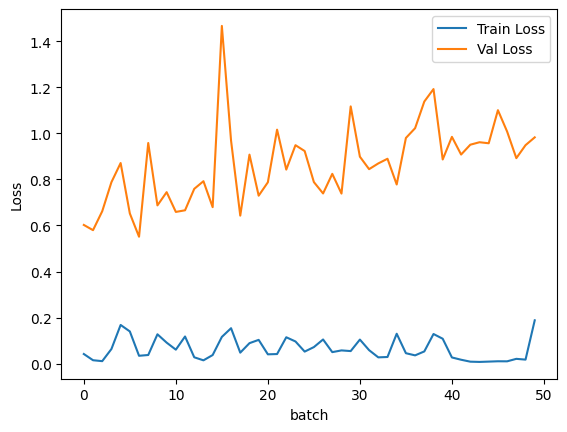

In [59]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("batch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [60]:
torch.save(model.state_dict(), 'model50.pt')

### 2.3 模型评估


- 对于意图识别和槽位填充模型的评估指标，一般来说，指标的值越高，表示模型性能越好。以下是对这些指标的合理区间和判断标准：

- 1. Intent Classification (意图识别)
  - intent_acc (意图分类准确率)：
区间：0 到 1（百分制为 0% 到 100%）
判断标准：70%以上通常表示模型具备较好的分类能力，85%到90%及以上则表示模型性能非常好。
  - intent_prec (意图分类精确率)：
区间：0 到 1
判断标准：精确率越高表示预测为某个意图的样本更准确，通常超过0.7表示性能较好，超过0.85表示非常好。
  - intent_rec (意图分类召回率)：
区间：0 到 1
判断标准：召回率越高表示模型能捕获更多真实的意图分类样本。通常超过0.7表示不错，0.85及以上则非常理想。
  - intent_f1 (意图分类F1值)：
区间：0 到 1
判断标准：F1值是精确率和召回率的平衡。一般来说，F1值超过0.75说明模型表现不错，0.85及以上则非常优秀。
- 2. Slot Filling (槽位填充)
  - slot_prec (槽位填充精确率)：
区间：0 到 1
判断标准：槽位填充任务中，精确率越高表示预测的槽位标签更准确。通常超过0.7表示模型不错，超过0.85表示模型在槽位填充上表现非常好。
  - slot_rec (槽位填充召回率)：
区间：0 到 1
判断标准：召回率越高表示模型能识别更多的正确槽位标签。超过0.7表示较好，超过0.85表示非常好。
  - slot_f1 (槽位填充F1值)：
区间：0 到 1
判断标准：F1值超过0.75表示模型在槽位填充任务上表现不错，超过0.85说明表现非常好。
- 3. Joint Accuracy (联合准确率)
  - joint_acc (联合准确率)：
区间：0 到 1
判断标准：联合准确率要求意图和槽位都正确，通常较低。超过0.6表示模型有较好表现，超过0.75表示模型非常好。
- 总结：
一般情况下：

对于intent_acc和slot_f1，在 0.75 以上可以认为模型效果较好，0.85 及以上为非常优秀。
joint_acc 通常低于单独的意图和槽位评分，但如果 0.65-0.75 之间则已经说明模型具备较强的整体预测能力，超过 0.75 则模型在意图和槽位联合任务上表现非常出色。
具体的数值还需要结合任务的复杂度、数据的多样性等进行判断。

In [63]:
model.eval()
all_pred_intents = []
all_true_intents = []
all_pred_slots = []
all_true_slots = []
val_step = 1

with torch.no_grad():
    for batch in val_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        seq_label_ids = batch['seq_label_ids'].to(device)  # 意图标签
        token_label_ids = batch['token_label_ids'].to(device)  # 槽位标签

        # 模型预测
        intent_logits, slot_logits = model(input_ids, attention_mask, token_type_ids)

        # 获取预测结果
        pred_intents = torch.argmax(intent_logits, dim=-1).cpu().numpy()  # 意图预测
        pred_slots = torch.argmax(slot_logits, dim=-1).cpu().numpy()  # 槽位预测

        all_pred_intents.extend(pred_intents)
        all_true_intents.extend(seq_label_ids.cpu().numpy())
        
        # 遍历每个样本并存储槽位预测
        for pred_slot, true_slot in zip(pred_slots, token_label_ids.cpu().numpy()):
            all_pred_slots.append(pred_slot[:len(true_slot)])  # 截取真实槽位长度部分
            all_true_slots.append(true_slot)

        val_step += 1
        print(val_step)
# 评估意图分类
intent_acc = accuracy_score(all_true_intents, all_pred_intents)
intent_prec, intent_rec, intent_f1, _ = precision_recall_fscore_support(all_true_intents, all_pred_intents, average='macro')

# 评估槽位填充
flat_pred_slots = [item for sublist in all_pred_slots for item in sublist]
flat_true_slots = [item for sublist in all_true_slots for item in sublist]
slot_prec, slot_rec, slot_f1, _ = precision_recall_fscore_support(flat_true_slots, flat_pred_slots, average='macro')

# 计算联合准确率
joint_correct = sum([p_int == t_int and np.array_equal(p_slot, t_slot) 
                        for p_int, p_slot, t_int, t_slot in zip(all_pred_intents, all_pred_slots, all_true_intents, all_true_slots)])
joint_accuracy = joint_correct / len(all_true_intents)

print({
    'intent_acc': intent_acc,
    'intent_prec': intent_prec,
    'intent_rec': intent_rec,
    'intent_f1': intent_f1,
    'slot_prec': slot_prec,
    'slot_rec': slot_rec,
    'slot_f1': slot_f1,
    'joint_acc': joint_accuracy
})

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
{'intent_acc': 0.8680297397769516, 'intent_prec': 0.6592122184172122, 'intent_rec': 0.5959378745777486, 'intent_f1': 0.6064112309751889, 'slot_prec': 0.3647066472925824, 'slot_rec': 0.3336121460236392, 'slot_f1': 0.3079164280540415, 'joint_acc': 0.42379182156133827}


/Users/bowie/anaconda3/envs/good/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowie/anaconda3/envs/good/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowie/anaconda3/envs/good/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [64]:
intent_logits.shape

torch.Size([2, 23])

In [65]:
torch.argmax(intent_logits, dim=-1).cpu().numpy()

array([1, 1])

In [66]:
slot_logits.shape

torch.Size([2, 32, 121])

In [68]:
torch.argmax(slot_logits, dim=-1).cpu().numpy()  # 槽位预测


array([[ 0,  0,  0,  1,  2,  2,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 69,  0,  0,  0,  0,  1,  2,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

In [69]:
batch['text']

['查询洛阳钼业的股票', '半夜不要照镜子']

### 2.4 模型预测

In [77]:
def predict(sentence, model, tokenizer, device, slot_label_list, intent_label_list, max_len=32):
    model.eval()
    # 对输入句子进行预处理
    inputs = tokenizer(
        sentence, 
        return_tensors="pt", 
        max_length=max_len, 
        padding="max_length", 
        truncation=True
    )
    
    # 将输入数据移动到指定设备上（如GPU或CPU）
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)

    with torch.no_grad():
        # 模型预测
        intent_logits, slot_logits = model(input_ids, attention_mask, token_type_ids)
        
        # 获取意图预测
        intent_pred = torch.argmax(intent_logits, dim=-1).cpu().numpy()[0]  # 取出意图预测的类别索引
        intent = intent_label_list[intent_pred]  # 根据索引获取意图标签

        # 获取槽位预测
        slot_preds = torch.argmax(slot_logits, dim=-1).cpu().numpy()[0]  # 槽位预测的类别索引
        slot_labels = [slot_label_list[i] for i in slot_preds]  # 根据索引获取槽位标签
        print(inputs)
        print(intent)
        print(slot_labels)
    # 获取原始输入的token长度，去除padding部分
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0], skip_special_tokens=True)
    print(tokens)
    slot_labels = slot_labels[1:len(tokens)]  # 仅保留有效token对应的槽位标签

    return {
        "sentence": sentence,
        "intent": intent,
        "slots": dict(zip(tokens, slot_labels))  # 将tokens与对应的槽位标签匹配
    }

# 示例
sentence = "我想订一张开封到甘肃去的机票"
predict_result = predict(sentence, model, tokenizer, device, slot_label_list=args.id2label, intent_label_list=args.id2cls)

print(f"Sentence: {predict_result['sentence']}")
print(f"Predicted Intent: {predict_result['intent']}")
print(f"Predicted Slots: {predict_result['slots']}")


{'input_ids': tensor([[ 101, 2769, 2682, 6370,  671, 2476, 2458, 2196, 1168, 4491, 5484, 1343,
         4638, 3322, 4873,  102,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])}
QUERY
['O', 'O', 'O', 'O', 'O', 'O', 'B-startLoc_city', 'I-startLoc_city', 'O', 'B-endLoc_city', 'I-endLoc_city', 'I-endLoc_city', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
['我', '想', '订', '一', '张', '开', '封', '到', '甘', '肃', '去', '的', '机', '票']
Sentence: 我想订一张开封到甘肃去的机票
Predicted Intent: QUERY
Predicted Slots: {'我': 'O', '想': 'O', '订': 'O', '一': 'O', '张': 'O', '开': 'B-startLoc_city', '封': 'I-startLoc_city', '到': 'O', '甘': 'B-endLoc_ci